# 30-Day Readmission Risk: Health Plan Care Management Model, EDA & Modeling

**Dataset:** [Diabetes 130-US Hospitals for Years 1999-2008](https://doi.org/10.24432/C5230J) (Clore, Cios, DeShazo & Strack, 2014; UCI ML Repository), 101,766 inpatient encounters for diabetic patients across 130 US hospitals.

**Business problem:** unplanned readmissions are one of the most expensive, most preventable-adjacent categories of medical spend a health plan carries. A care-management team can't call every recently discharged member, so this model scores each discharge so that limited outreach capacity (a call, medication reconciliation, an early follow-up visit) goes to the members most likely to bounce back within 30 days. It's the same signal CMS's Hospital Readmissions Reduction Program (HRRP) penalizes *hospitals* on, which is why payers and provider systems both build this kind of model from opposite sides of the same incentive.

**Target:** `readmitted == "<30"`, readmitted to any hospital within 30 days of this discharge.


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import load_raw, clean_and_engineer, TARGET

pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")

raw = load_raw("../data/raw/diabetic_data.csv")
raw.shape

(101766, 50)

## 1. First look at the raw data

In [2]:
raw[["encounter_id", "patient_nbr", "race", "gender", "age", "time_in_hospital", "readmitted"]].head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),1,NO
1,149190,55629189,Caucasian,Female,[10-20),3,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),2,NO
3,500364,82442376,Caucasian,Male,[30-40),2,NO
4,16680,42519267,Caucasian,Male,[40-50),1,NO


In [3]:
raw["readmitted"].value_counts(normalize=True).rename("share").to_frame()

,share
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


There are three outcome classes in the raw data: no readmission, readmission after 30 days, and readmission within 30 days (the one HRRP penalizes hospitals on, and the one this project predicts). Roughly 11% of encounters are followed by a <30-day readmission, before excluding encounters that ended in death or hospice, which can't be meaningfully "readmitted."

Also worth flagging up front: this dataset has **101,766 encounters but only ~71,500 unique patients**. Some patients appear multiple times. A random row-level train/test split would leak a patient's other encounters across the split and inflate apparent accuracy, so the modeling pipeline (`src/train.py`) splits on `patient_nbr` instead. Section 6 below quantifies exactly how much that would have inflated the numbers.

In [4]:
print("Encounters:", len(raw))
print("Unique patients:", raw["patient_nbr"].nunique())
print("Patients with >1 encounter:", (raw["patient_nbr"].value_counts() > 1).sum())

Encounters: 101766
Unique patients: 71518
Patients with >1 encounter: 16773


## 2. Missingness and data quality

In [5]:
missing = raw.replace("?", pd.NA).isna().mean().sort_values(ascending=False)
missing[missing > 0].rename("pct_missing").to_frame()

,pct_missing
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
race,0.022336
diag_3,0.013983
diag_2,0.003518
diag_1,0.000206


`weight` is missing for ~97% of records and gets dropped entirely since it's not usable at that rate. `medical_specialty` is missing for ~49% and gets kept as its own "Missing" category, since the fact that specialty wasn't recorded can itself carry signal, e.g. which department a patient was under. `payer_code` is missing for ~40% and gets dropped since it isn't clinically meaningful for readmission risk anyway. `race` is missing for ~2% and gets imputed as "Unknown" rather than dropped.

In [6]:
raw["discharge_disposition_id"].value_counts().head(10)

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64

Discharge disposition codes 11, 13, 14, 19, 20 and 21 mean the patient died or was discharged to hospice (see `data/reference/ids_mapping.csv`, pulled from the dataset's own documentation). Those encounters get excluded rather than counted as "not readmitted," since the two aren't the same thing.

## 3. Cleaning & feature engineering

In [7]:
clean = clean_and_engineer(raw)
print(f"Rows: {len(raw):,} -> {len(clean):,} after excluding deaths/hospice/invalid-gender rows")
print(f"30-day readmission rate after cleaning: {clean[TARGET].mean():.2%}")
clean.shape

Rows: 101,766 -> 99,340 after excluding deaths/hospice/invalid-gender rows
30-day readmission rate after cleaning: 11.39%


(99340, 54)

Key engineered features: ICD-9 primary, secondary, and tertiary diagnosis codes collapsed into 9 broad clinical categories (circulatory, diabetes, respiratory, and so on) following the grouping in the original Strack et al. paper; `total_prior_visits`, the sum of prior outpatient, emergency, and inpatient visits, since utilization history is one of the strongest readmission predictors in the literature; `num_medication_changes`, a count of diabetes medications titrated up or down this visit; and age bucket midpoints converted to a numeric feature.

## 4. What separates readmitted patients from non-readmitted?

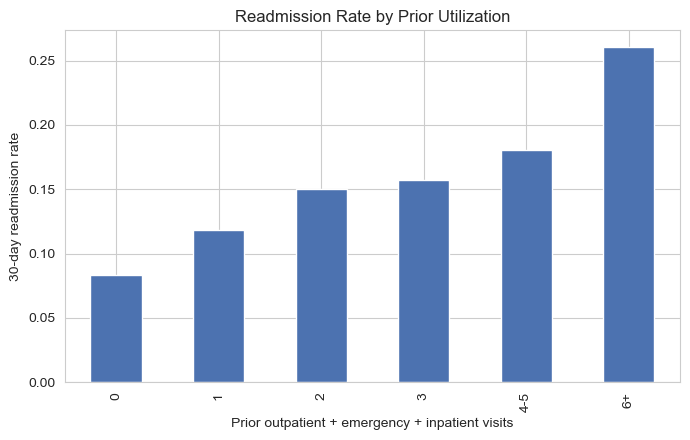

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bucket = pd.cut(clean["total_prior_visits"], [-1, 0, 1, 2, 3, 5, 100], labels=["0", "1", "2", "3", "4-5", "6+"])
rate = clean.groupby(bucket, observed=True)[TARGET].mean()
rate.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Prior outpatient + emergency + inpatient visits")
ax.set_ylabel("30-day readmission rate")
ax.set_title("Readmission Rate by Prior Utilization")
fig.tight_layout()
plt.show()

A patient with 6+ prior visits is readmitted within 30 days at roughly **3x** the rate of a patient with none. Utilization history is doing a lot of the work here, which lines up with how readmission-risk models are usually described in the clinical literature.

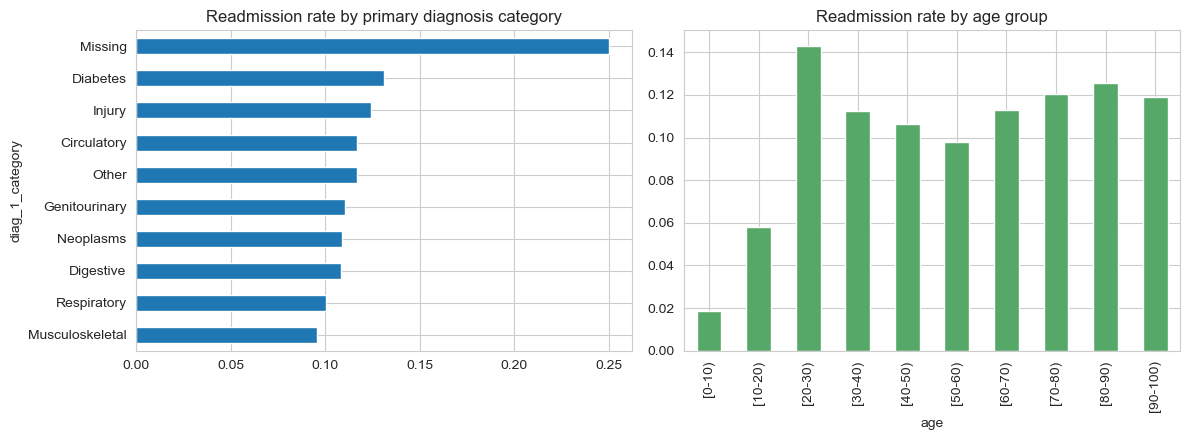

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clean.groupby("diag_1_category", observed=True)[TARGET].mean().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Readmission rate by primary diagnosis category")
clean.groupby("age", observed=True)[TARGET].mean().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Readmission rate by age group")
fig.tight_layout()
plt.show()

## 5. Modeling, evaluation, and subgroup checks

Full training pipeline lives in `src/train.py`: an XGBoost model with native categorical support vs. two challengers, a logistic regression on the same features and the **LACE index** hospitals already use (`src/lace.py`), all evaluated on a **patient-level** held-out split (no patient's encounters appear in both train and test). Neither model uses class weighting, for reasons the calibration section below makes clear. Race is deliberately excluded from the model's features, see the module docstring in `src/train.py` for why, but checked afterwards along with age and sex.

Every headline metric comes with a 95% confidence interval from a bootstrap that resamples *patients* rather than encounters (`src/evaluation.py`), since the test set still has repeat visits from the same people.

In [10]:
import json
with open("../models/metrics.json") as f:
    metrics = json.load(f)

ci = metrics["confidence_intervals"]
def fmt(m, key, pct=False):
    v = ci[m][key]
    if pct:
        return f"{v['estimate']:.1%} [{v['ci_low']:.1%}, {v['ci_high']:.1%}]"
    return f"{v['estimate']:.3f} [{v['ci_low']:.3f}, {v['ci_high']:.3f}]"

pd.DataFrame({
    label: {
        "ROC-AUC": fmt(m, "roc_auc"),
        "PR-AUC": fmt(m, "pr_auc"),
        "Caught in top 10%": fmt(m, "top_decile_capture_rate", pct=True),
        "Caught in top 20%": fmt(m, "top_quintile_capture_rate", pct=True),
        "Brier score": f"{metrics[m]['calibration']['brier_score']:.4f}",
    }
    for m, label in [("lace", "LACE index"), ("logistic_regression", "Logistic regression"), ("xgboost", "XGBoost")]
}).T

,ROC-AUC,PR-AUC,Caught in top 10%,Caught in top 20%,Brier score
LACE index,"0.571 [0.558, 0.583]","0.138 [0.130, 0.146]","14.4% [13.3%, 15.9%]","27.7% [26.0%, 29.4%]",0.0993
Logistic regression,"0.667 [0.656, 0.679]","0.220 [0.201, 0.240]","23.2% [21.6%, 24.8%]","38.6% [36.9%, 40.2%]",0.0956
XGBoost,"0.677 [0.665, 0.689]","0.235 [0.216, 0.255]","25.4% [23.6%, 27.0%]","40.4% [38.5%, 42.3%]",0.0947


**ROC-AUC of about 0.68 is the honest result for this task, not a shortcoming to explain away.** Predicting a 30-day hospital readmission from administrative and encounter data alone is a genuinely hard problem. It depends heavily on social factors (housing stability, caregiver support, medication adherence) that simply aren't in this dataset. Published academic and applied analyses of this exact dataset land in the same 0.65-0.70 AUC range, so a model claiming 0.90+ on this task would be a red flag for leakage, not a sign of a better model. What actually matters for the care-management use case is ranking, not raw discrimination:

In [11]:
print(f"Top-decile capture rate: {metrics['xgboost']['top_decile_capture_rate']:.0%} of readmissions caught by flagging the riskiest 10% of discharges")
print(f"Top-quintile capture rate: {metrics['xgboost']['top_quintile_capture_rate']:.0%} of readmissions caught by flagging the riskiest 20% of discharges")

Top-decile capture rate: 25% of readmissions caught by flagging the riskiest 10% of discharges
Top-quintile capture rate: 40% of readmissions caught by flagging the riskiest 20% of discharges


### Does it beat the clinical standard?

Beating a logistic regression isn't really the bar. Plenty of hospitals already flag readmission risk with the [LACE index](https://doi.org/10.1503/cmaj.091117) (van Walraven et al., 2010), a 0-19 point score built from **L**ength of stay, **A**cuity of admission, **C**omorbidity (Charlson index), and **E**mergency department visits. `src/lace.py` computes it from the same encounter data, including a Charlson index mapped from the ICD-9 codes (Quan et al. 2005 coding). The differences below are computed on the same bootstrap resamples, so the interval accounts for both models being scored on the same patients.

In [12]:
rows = {}
for pair, label in [("xgboost_minus_lace", "XGBoost minus LACE"), ("xgboost_minus_logistic_regression", "XGBoost minus logistic regression")]:
    rows[label] = {
        "ROC-AUC difference": fmt(pair, "roc_auc"),
        "Top-20% capture difference": fmt(pair, "top_quintile_capture_rate", pct=True),
    }
pd.DataFrame(rows).T

,ROC-AUC difference,Top-20% capture difference
XGBoost minus LACE,"0.106 [0.091, 0.120]","12.7% [10.3%, 15.1%]"
XGBoost minus logistic regression,"0.010 [0.004, 0.016]","1.8% [0.4%, 3.1%]"


XGBoost beats LACE by about 0.11 of AUC and catches roughly 13 more percentage points of readmissions in the riskiest fifth of discharges, with both intervals far from zero. LACE is working with a handicap here: this dataset only has three diagnosis codes per encounter, so its Charlson score undercounts comorbidities, and ED visits cover the prior year instead of LACE's 6 months. Even so, LACE reached a C-statistic of 0.68 in its original derivation study and usually does worse in external validations, so a gap this size says the utilization history, discharge disposition, and medication detail carry real signal a four-item score can't pick up.

The gain over logistic regression is much smaller (about 0.01 AUC, though the interval clears zero). Most of the improvement over LACE comes from the richer features, not the algorithm.

### Is the model calibrated?

Ranking members correctly is half the job. The payer-economics section right after this one takes the predicted probabilities and multiplies them straight into dollar figures, which only makes sense if those probabilities are actually close to the true readmission rate and not just correctly ordered. `_plot_calibration` in `src/train.py` checks this directly by bucketing predictions and comparing the average predicted risk in each bucket against the observed readmission rate in that bucket.

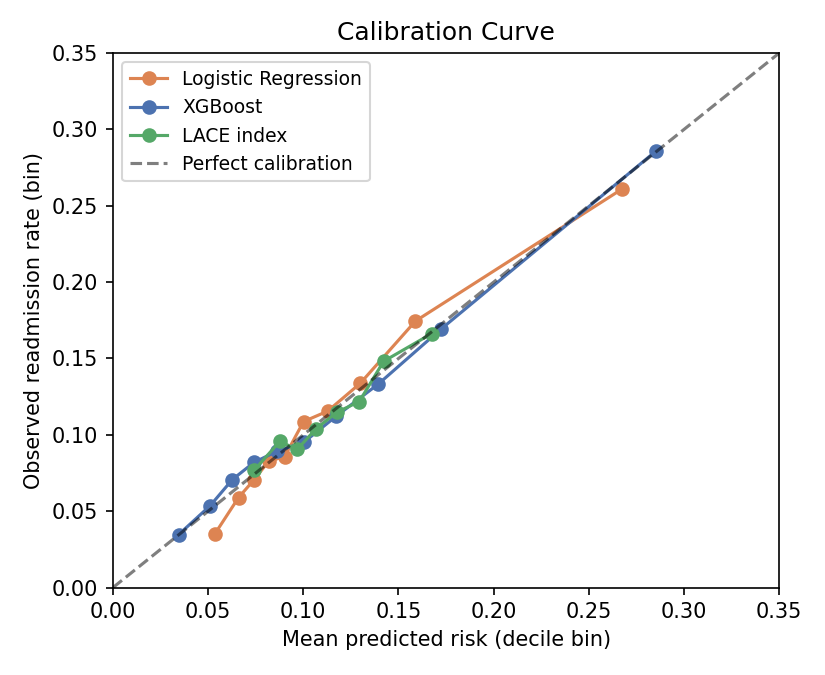

In [13]:
from IPython.display import Image
Image("../reports/figures/calibration.png")

All three track the diagonal closely. XGBoost's mean predicted risk is 11.2% against an observed 11.3%, with a calibration slope of 0.95 (1.0 is ideal):

In [14]:
pd.DataFrame({m: metrics[m]["calibration"] for m in ["xgboost", "logistic_regression", "lace"]}).T

,brier_score,mean_predicted_risk,observed_rate,observed_to_expected,calibration_slope
xgboost,0.0947,0.1124,0.1127,1.002,0.953
logistic_regression,0.0956,0.1135,0.1127,0.993,1.032
lace,0.0993,0.1139,0.1127,0.989,0.961


That wasn't true of the first version of this model, and this check is how it got caught. Training with `scale_pos_weight`, the usual advice for an imbalanced target, left the ranking essentially unchanged but pushed the mean predicted risk to about 0.43, nearly four times the real rate. For pure ranking that's harmless. For anything that multiplies a probability by a dollar amount, like the next two sections, it's badly wrong. Dropping the class weighting fixed it with no loss in AUC and roughly halved the Brier score.

### Why the patient-level split actually matters

Section 1 mentioned that a random row-level split would let a patient's encounters leak across train and test. It's one thing to say that leaks and another to show what it's worth. `src/train.py` also fits the identical XGBoost architecture on a plain stratified row-level split that ignores `patient_nbr` entirely, so the same patient can and does land in both sides of that split.

In [15]:
naive = metrics["naive_split_comparison"]
comparison = pd.DataFrame({
    "patient-level split (used everywhere else)": {
        "roc_auc": metrics["xgboost"]["roc_auc"],
        "pr_auc": metrics["xgboost"]["pr_auc"],
        "pct_test_patients_also_in_train": 0.0,
    },
    "naive row-level split": {
        "roc_auc": naive["roc_auc"],
        "pr_auc": naive["pr_auc"],
        "pct_test_patients_also_in_train": naive["pct_test_patients_also_seen_in_train"],
    },
}).T
comparison

,roc_auc,pr_auc,pct_test_patients_also_in_train
patient-level split (used everywhere else),0.6770,0.2345,0.0000
naive row-level split,0.6806,0.2367,0.3577


With about 36% of the naive split's test patients also present in its training set, ROC-AUC comes in roughly 0.3 points higher than the patient-level split. That's real but smaller than the leakage horror stories you sometimes see written up, and it's an interesting result on its own. `patient_nbr` isn't a feature, so the model can't directly memorize "this ID is high risk." What leaks instead is subtler: two encounters from the same patient tend to share similar demographic and clinical values, so seeing one in training gives the model a small edge on the other at test time, even without the ID itself. A third of a point of AUC doesn't sound dramatic, but on a model already this close to its ceiling, it's exactly the kind of quiet optimism a real validation process is supposed to catch before it ever reaches a production dashboard.

### What that's worth in payer terms

AHRQ's Healthcare Cost and Utilization Project puts the average cost of an adult 30-day readmission at **$17,700** (2020 Nationwide Readmissions Database; [HCUP Statistical Brief #307](https://hcup-us.ahrq.gov/reports/statbriefs/sb307-readmissions-2020.jsp)). Applying that to this test set reframes the capture-rate numbers above as cost concentration, not just model accuracy. This is the pitch a payer-side data science team actually has to make to get care-management outreach headcount funded, and it only holds up if the predicted probabilities behind it are trustworthy, which is what the calibration check above was for.

In [16]:
AVG_READMISSION_COST = 17_700  # AHRQ HCUP Statistical Brief #307 (2020, adult readmissions)

total_encounters = metrics["test_set"]["encounters"]
total_readmits = metrics["test_set"]["readmissions_30d"]

rows = []
for pct, key in [(0.10, "top_decile_capture_rate"), (0.20, "top_quintile_capture_rate")]:
    reviewed = int(total_encounters * pct)
    captured = round(total_readmits * metrics["xgboost"][key])
    rows.append({
        "Outreach target": f"Top {int(pct*100)}% by risk score",
        "Discharges reviewed": reviewed,
        "Readmissions captured": captured,
        "Cost exposure captured": f"${captured * AVG_READMISSION_COST:,.0f}",
    })
rows.append({
    "Outreach target": "All readmissions",
    "Discharges reviewed": total_encounters,
    "Readmissions captured": total_readmits,
    "Cost exposure captured": f"${total_readmits * AVG_READMISSION_COST:,.0f}",
})
pd.DataFrame(rows)

,Outreach target,Discharges reviewed,Readmissions captured,Cost exposure captured
0,Top 10% by risk score,2475,708,"$12,531,600"
1,Top 20% by risk score,4951,1127,"$19,947,900"
2,All readmissions,24757,2789,"$49,365,300"


### Is acting on the model worth it?

AUC says whether the model ranks members well, not whether *using* it beats the obvious alternatives of calling every discharged member or calling no one. Decision curve analysis (Vickers & Elkin, 2006) answers that. At each threshold probability *p*, net benefit is readmissions caught per discharge minus false alarms weighted by *p*/(1 − *p*), the trade-off that choosing *p* implies.

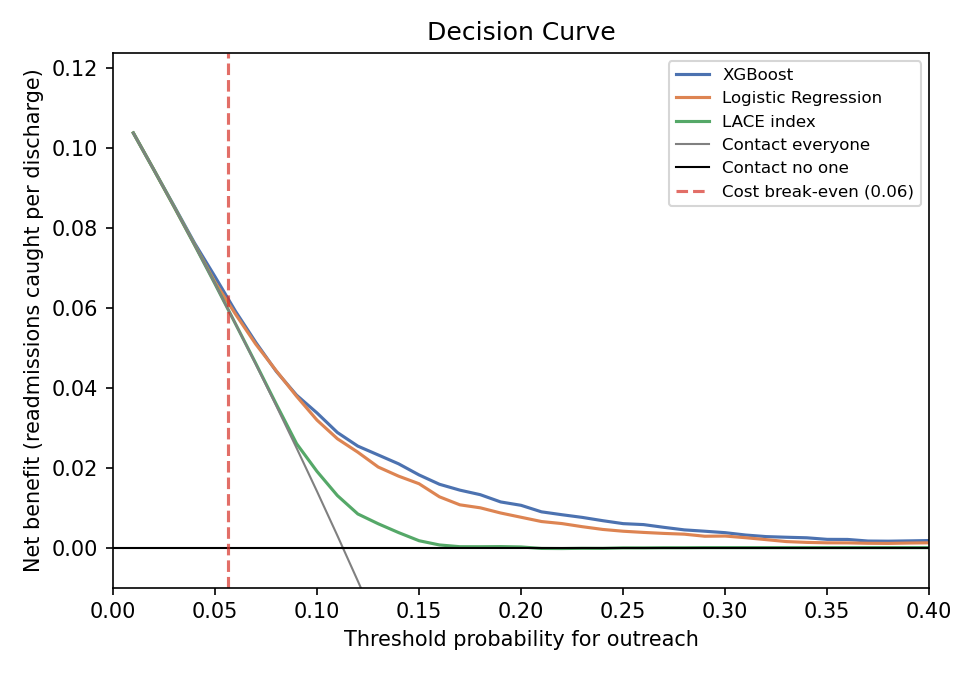

In [17]:
Image("../reports/figures/decision_curve.png")

In [18]:
pd.DataFrame(metrics["decision_curve"]["net_benefit_at_selected_thresholds"]).T

,xgboost,logistic_regression,lace,treat_all
0.06,0.05915,0.05844,0.05602,0.05602
0.10,0.03367,0.03188,0.01905,0.01406
0.15,0.01817,0.01597,0.00172,-0.04394
0.20,0.01057,0.00758,0.00016,-0.10918
0.30,0.00373,0.00289,0.00000,-0.26764


XGBoost has the highest net benefit at nearly every threshold from 0.03 up, and its lead widens past 0.10. LACE only beats the default policies between roughly 0.07 and 0.15. Below about 0.06 every model converges on "contact nearly everyone," which is the same place the cost analysis below ends up.

### Picking an operating threshold

If cost rather than headcount is the binding constraint, `src/threshold_optimization.py` sweeps every threshold and computes net savings versus no program: avoided readmission cost on flagged true positives, minus outreach cost on everyone flagged. The cost-per-contact ($150) and effectiveness (15% relative risk reduction) are scenario inputs, not measured results.

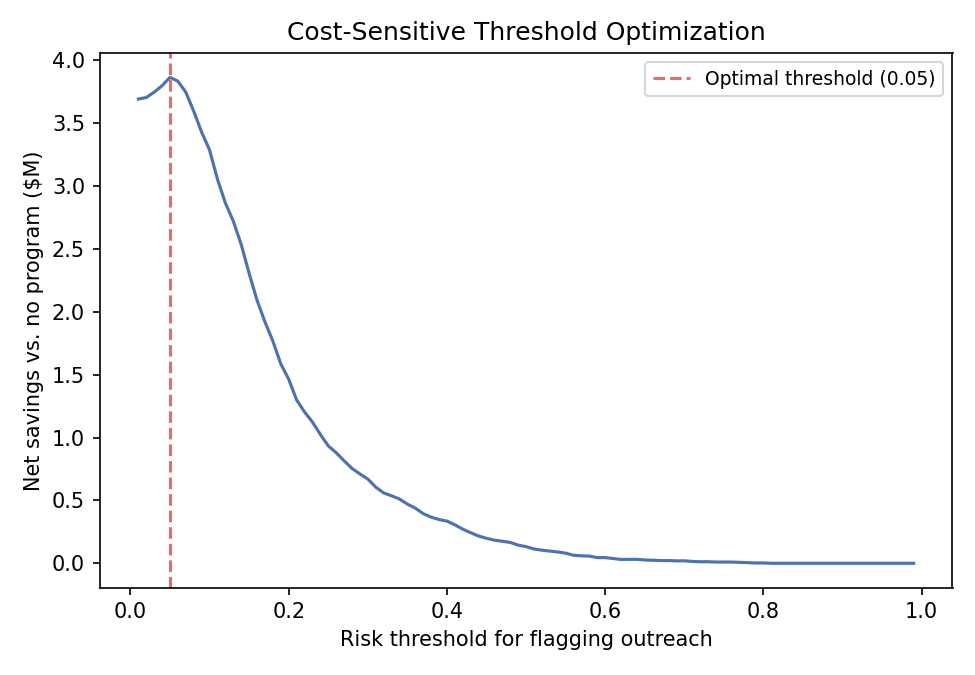

In [19]:
Image("../reports/figures/cost_threshold_curve.png")

In [20]:
opt = metrics["threshold_optimization"]
print(f"Break-even risk at base case: {150 / (17_700 * 0.15):.1%}")
print(f"Optimal threshold: {opt['base_case_optimal_threshold']:.2f}, flagging {opt['base_case_flagged_pct']:.0%} of discharges, net savings ${opt['base_case_net_savings']:,.0f}")
pd.DataFrame(opt["sensitivity_by_effectiveness"]).T

Break-even risk at base case: 5.6%
Optimal threshold: 0.05, flagging 86% of discharges, net savings $3,864,900


,optimal_threshold,flagged_pct,net_savings
10%_effectiveness,0.08,0.6006,1653030.0
15%_effectiveness,0.05,0.8610,3864900.0
20%_effectiveness,0.05,0.8610,6219000.0


At $150 a call and 15% effectiveness, outreach pays for itself once a member's risk passes about 5.6%, half the base rate, so the optimal policy flags most discharges. Because the probabilities are calibrated, the optimal threshold (0.05) lands right on that break-even point, which is a useful sanity check in its own right. With the earlier, uncalibrated model the same sweep put the optimum at 0.28, a number that looked plausible and meant nothing.

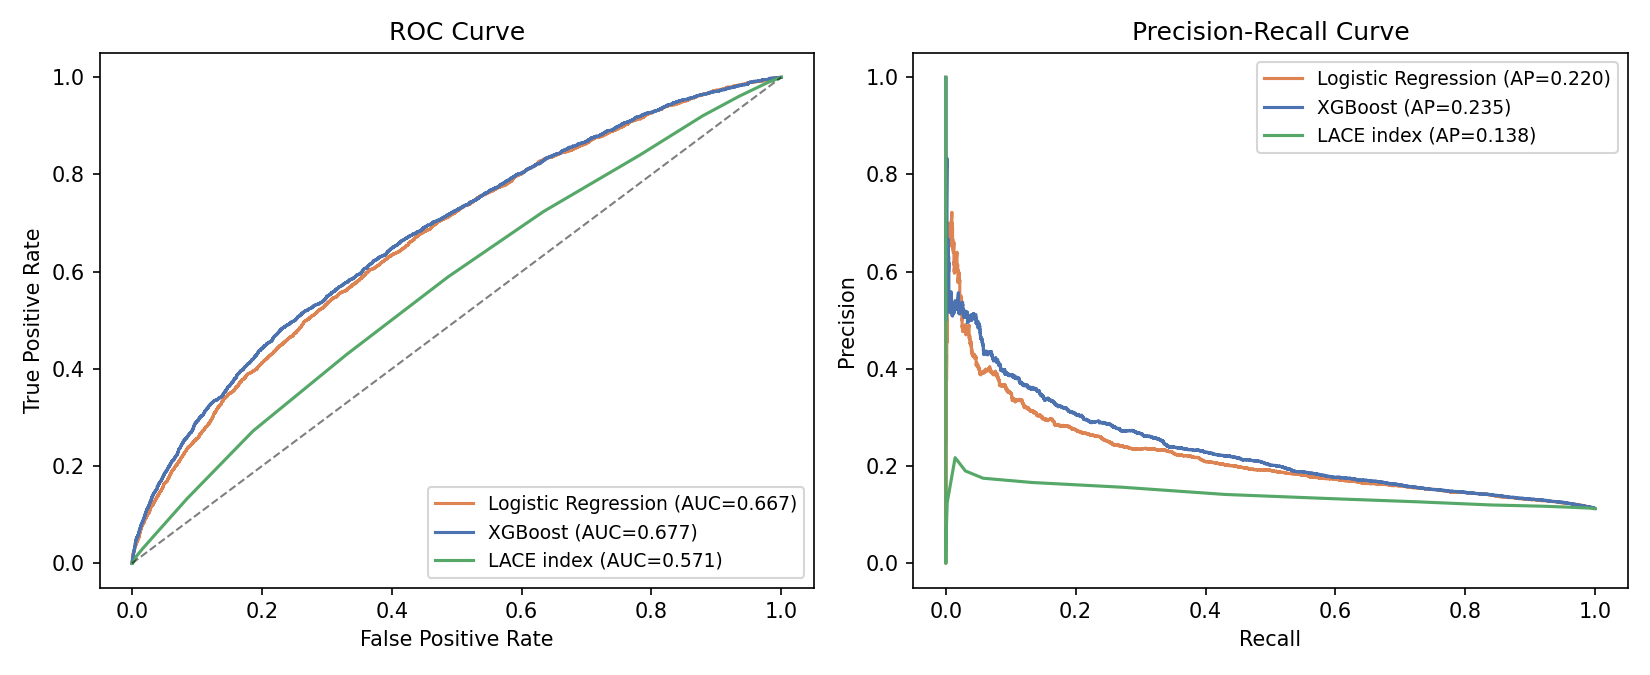

In [21]:
from IPython.display import Image
Image("../reports/figures/roc_pr_curves.png")

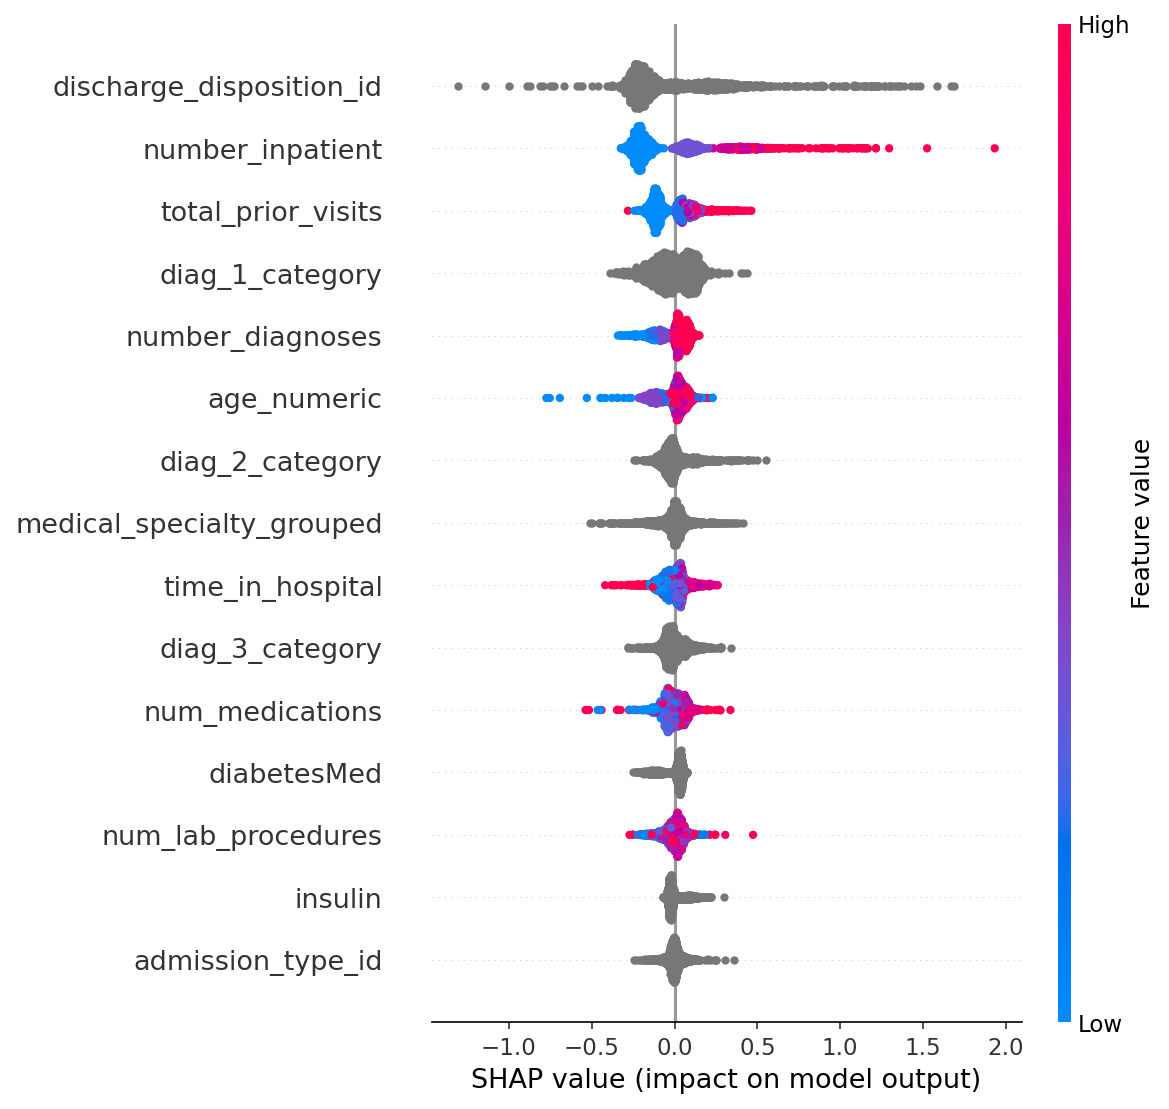

In [22]:
Image("../reports/figures/shap_summary.png")

SHAP confirms prior inpatient visits, discharge disposition, and primary diagnosis dominate the prediction. All of that is clinically sensible and consistent with the EDA above.

### Subgroup checks

Every group gets the same outreach cutoff, the score that marks the riskiest 20% of discharges overall, so the question is whether one policy lands differently on different members. Groups under 200 encounters are left out as too noisy.

In [23]:
cols = ["n", "observed_rate", "mean_predicted_risk", "roc_auc", "flagged_rate", "recall_when_flagged", "false_positive_rate"]
pd.concat(
    {name: pd.DataFrame(groups).T[cols] for name, groups in metrics["subgroup_performance"].items()},
    names=["dimension", "group"],
)

n  observed_rate  mean_predicted_risk  \
dimension group                                                          
race      AfricanAmerican   4607.0         0.1083               0.1119   
          Caucasian        18563.0         0.1153               0.1135   
          Hispanic           507.0         0.0966               0.1036   
          Other              361.0         0.1108               0.1010   
          Unknown            561.0         0.0802               0.0976   
age_band  Under 50          3929.0         0.1038               0.1009   
          50-59             4316.0         0.1066               0.0982   
          60-69             5390.0         0.1139               0.1114   
          70-79             6299.0         0.1124               0.1198   
          80+               4823.0         0.1242               0.1258   
gender    Female           13395.0         0.1125               0.1137   
          Male             11362.0         0.1128               0.1108   

                           roc_auc  flagged_rate  recall_when_flagged  \
dimension group                                                         
race      AfricanAmerican   0.6704        0.2125               0.4048   
          Caucasian         0.6772        0.2007               0.4068   
          Hispanic          0.7448        0.1854               0.4286   
          Other             0.6880        0.1357               0.4000   
          Unknown           0.6275        0.1426               0.2889   
age_band  Under 50          0.7125        0.1736               0.4289   
          50-59             0.7235        0.1532               0.4022   
          60-69             0.6717        0.1933               0.3876   
          70-79             0.6592        0.2267               0.4223   
          80+               0.6233        0.2362               0.3840   
gender    Female            0.6846        0.2053               0.4200   
          Male              0.6684        0.1938               0.3853   

                           false_positive_rate  
dimension group                                 
race      AfricanAmerican               0.1891  
          Caucasian                     0.1738  
          Hispanic                      0.1594  
          Other                         0.1028  
          Unknown                       0.1298  
age_band  Under 50                      0.1440  
          50-59                         0.1234  
          60-69                         0.1683  
          70-79                         0.2019  
          80+                           0.2152  
gender    Female                        0.1781  
          Male                          0.1694

Calibration holds up for every sizable group, with predicted risk within about a percentage point of observed, and recall at the shared cutoff stays around 38-43% across race, age, and sex. A readmitted member has a similar chance of being flagged regardless of group. Two things are worth flagging. Discrimination falls steadily with age, from about 0.72 under 60 to 0.62 at 80+, probably because readmission among the oldest members depends more on frailty and home support than on anything recorded here. And members whose race wasn't recorded have lower recall (29%), though with about 45 readmissions in that group the estimate is noisy. None of this replaces a full fairness audit before real deployment, but it's the check that should run on every retrain, and it's why race was left out of the features in the first place rather than kept because it "improved AUC."